# 3a. BE vs SC Grid-Search Cross-Validation

**Purpose**: Classify each animal as BE or SC using the manuscript's
grid-search CV procedure on the update matrix.

**Protocol** (matching manuscript):
1. Expert sessions: last 50% of Uniform sessions with accuracy ≥ 70%
2. Pool trials, split into 2 folds by session blocks
3. Grid search: σ_percep × A_repulsion × model params → ~8,000 combos
4. 64 seeds → 64 test errors per model per animal
5. ANOVA: compare BE vs SC error distributions

**Data flow**: Cluster pickles → load → ANOVA → visualisation → parameter report

**Sections**:
1. Setup
2. Load cluster results
3. ANOVA model comparison
4. Per-animal comparison plots
5. Winner summary
6. Best-fit parameters
7. Empirical vs model update matrices
8. Parameter distributions across seeds
9. Save

## 1. Setup

In [1]:
from shared_setup import *

from behav_utils.plotting.styles import COLOURS, apply_style
from analysis.grid_search import _sessions_to_arrays, _simulate_um, grid_search_cv, COARSE_GRID
from analysis.cv_utils import (
    load_cv_pickles, build_long_df, run_anova,
    build_summary_table, extract_param_df, summarise_loaded_results,
)
from plotting.cv import plot_winner_summary

apply_style()

In [2]:
CONFIG_PATH = PATH_CONFIG
CV_RESULTS_DIR = Path('../results/cv')
OUTPUT_DIR = Path('../results/cv/figures')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Expert session criteria (must match cluster job)
EXPERT_MIN_ACCURACY = 0.70
EXPERT_LAST_FRACTION = 0.50
N_BINS = 8

## 2. Load Cluster Results

Cluster job (`submit_cv.sh` → `run_cv_single.py`) produces one pickle
per animal per seed: `cv_{ANIMAL}_seed{NNN}.pkl`.
`gather_cv_results.py` merges these. `load_cv_pickles` loads them.

In [3]:
# ── Load cluster results, or run quick validation ────────────────────────────
try:
    all_results = load_cv_pickles(str(CV_RESULTS_DIR))
    print(f'Loaded cluster results for {len(all_results)} animals')
except FileNotFoundError:
    all_results = {}

if not all_results:
    print('No cluster results found. Running quick coarse grid-search...')
    import pickle
    experiment_gs, _ = load_data()
    all_animals = experiment_gs.get_animals(min_sessions=10, stage=STAGE)
    quick_animals = all_animals[:min(2, len(all_animals))]

    CV_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

    for animal in quick_animals:
        aid = animal.animal_id
        sessions = animal.get_sessions(stage=STAGE)
        expert = sessions[len(sessions)//2:]
        if len(expert) < 4:
            print(f'  {aid}: too few sessions, skipping')
            continue

        for seed in [1, 2]:
            # Match cluster format: one pickle per (animal, seed)
            # containing {'BE': {...}, 'SC': {...}}
            seed_results = {}
            for mt in ['BE', 'SC']:
                try:
                    
                    result = grid_search_cv(
                        expert, mt, grid=COARSE_GRID[mt],
                        n_folds=2, seed=seed, burn_in=500,
                    )
                    seed_results[mt] = {
                        'avg_test_error': result['avg_test_error'],
                        'test_errors': result['test_errors'],
                        'best_params': result['best_params'],
                        'best_params_single': result['best_params_single'],
                        'model': mt,
                        'seed': seed,
                    }
                    print(f'  {aid} {mt} seed={seed}: err={result["avg_test_error"]:.4f}')
                except Exception as e:
                    print(f'  {aid} {mt} seed={seed}: FAILED ({e})')
                    seed_results[mt] = {
                        'avg_test_error': np.nan,
                        'test_errors': [],
                        'best_params': None,
                        'best_params_single': None,
                        'model': mt,
                        'seed': seed,
                    }

            fname = CV_RESULTS_DIR / f'cv_{aid}_seed{seed:03d}.pkl'
            with open(fname, 'wb') as f:
                pickle.dump(seed_results, f)

    # Reload in standard format
    try:
        all_results = load_cv_pickles(str(CV_RESULTS_DIR))
        print(f'\nQuick results: {len(all_results)} animals')
    except FileNotFoundError:
        print('No results produced — check data loading')
        all_results = {}

No cluster results found. Running quick coarse grid-search...
Loaded 12 animals, 433 total sessions
Loaded 12 animals, 433 sessions from CSV
  SS01 BE seed=1: err=0.0123
  SS01 SC seed=1: err=0.0086
  SS01 BE seed=2: err=0.0080
  SS01 SC seed=2: err=0.0125
  SS04 BE seed=1: err=0.0060
  SS04 SC seed=1: err=0.0061
  SS04 BE seed=2: err=0.0060
  SS04 SC seed=2: err=0.0067

Quick results: 2 animals


In [4]:
long_df = build_long_df(all_results)
print(f'Long DataFrame: {len(long_df)} rows')
print(f'Animals: {long_df["animal_id"].nunique()}')
print(f'Seeds per animal per model: '
      f'{long_df.groupby(["animal_id", "model"]).size().unique()}')
print()
long_df.groupby(['animal_id', 'model'])['avg_test_error'].agg(
    ['mean', 'std', 'count']
)

Long DataFrame: 8 rows
Animals: 2
Seeds per animal per model: [2]



mean       std  count
animal_id model                           
SS01      BE     0.010136  0.003028      2
          SC     0.010590  0.002746      2
SS04      BE     0.005981  0.000006      2
          SC     0.006412  0.000459      2

## 3. ANOVA Model Comparison

For each animal: 64 BE test errors vs 64 SC test errors.
One-way ANOVA tests whether the means differ. The model with
lower mean error wins (if p < 0.05).

In [5]:
comparison_df = run_anova(long_df)
print(comparison_df[['animal_id', 'be_mean', 'sc_mean', 'p_value', 'winner']].to_string(index=False))

animal_id  be_mean  sc_mean  p_value       winner
     SS01 0.010136 0.010590 0.889815 Inconclusive
     SS04 0.005981 0.006412 0.316145 Inconclusive


## 4. Per-Animal Comparison Plots

Violin plots of test error distributions + paired scatter.

In [7]:
from plotting.cv import plot_cv_comparison

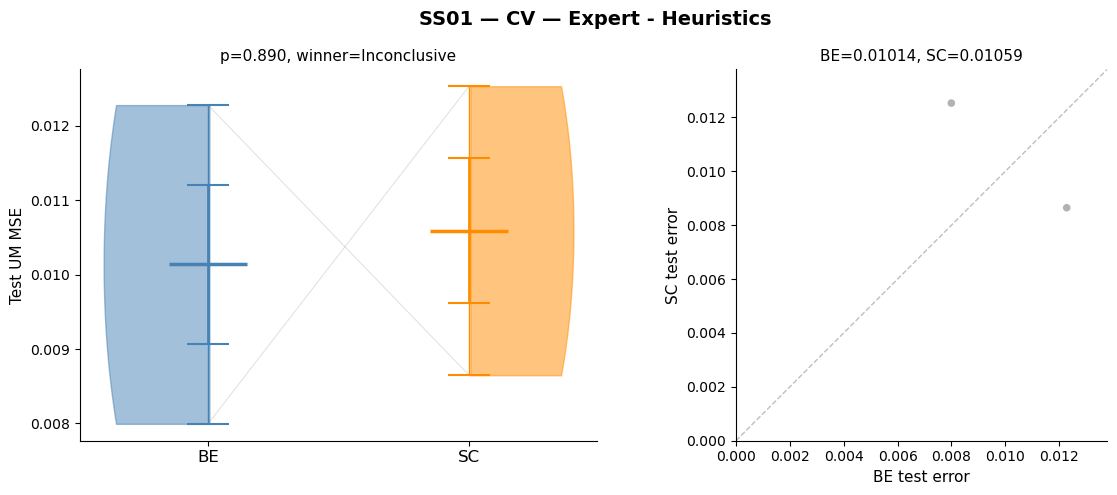

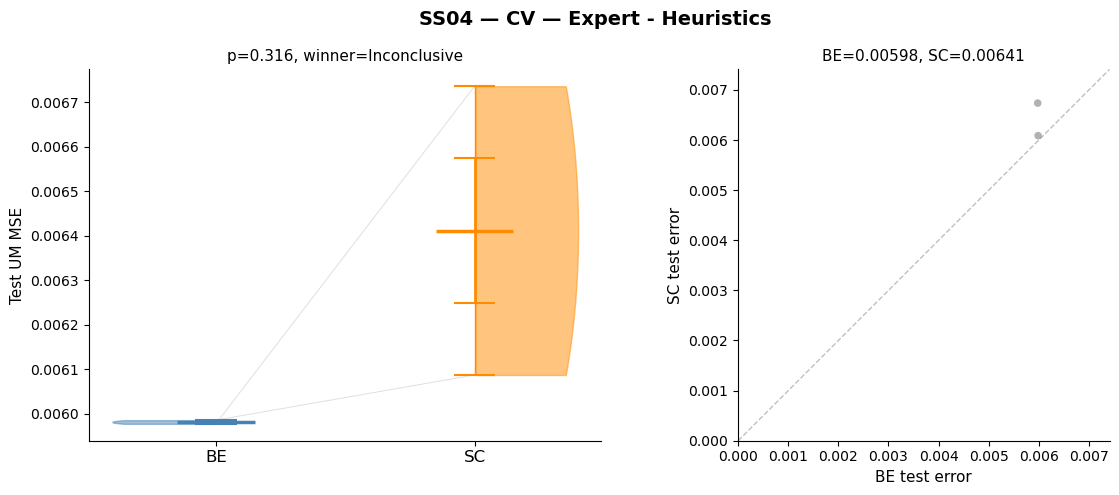

In [8]:
for aid in sorted(long_df['animal_id'].unique()):
    fig = plot_cv_comparison(
        long_df, comparison_df, aid,
        fit_target='UM', output_dir=str(OUTPUT_DIR),
    )
    plt.show()
    plt.close(fig)

## 5. Winner Summary

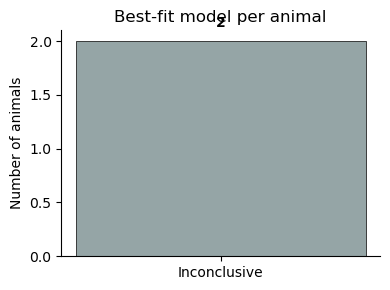

BE: 0, SC: 0, NS: 0 / 2 animals


In [9]:
fig = plot_winner_summary(comparison_df, output_dir=str(OUTPUT_DIR))
plt.show()

n_be = (comparison_df['winner'] == 'BE').sum()
n_sc = (comparison_df['winner'] == 'SC').sum()
n_ns = (comparison_df['winner'] == 'NS').sum()
print(f'BE: {n_be}, SC: {n_sc}, NS: {n_ns} / {len(comparison_df)} animals')

## 6. Best-Fit Parameters

For each animal, extract the winning model's parameters from the
seed with lowest test error.

In [10]:
summary_df = build_summary_table(all_results, comparison_df)
summary_df

,animal_id,winner,p_value,be_mean_error,sc_mean_error
0,SS01,Inconclusive,0.889815,0.010136,0.010590
1,SS04,Inconclusive,0.316145,0.005981,0.006412


In [11]:
for _, row in summary_df.iterrows():
    aid = row['animal_id']
    winner = row['winner']
    p = row['p_value']
    print(f'\n{aid}: winner = {winner} (p = {p:.2e})')
    print(f'  BE mean error = {row["be_mean_error"]:.5f}')
    print(f'  SC mean error = {row["sc_mean_error"]:.5f}')
    if winner in ('BE', 'SC'):
        param_cols = [c for c in summary_df.columns
                      if c.startswith('best_') and c != 'best_seed']
        print(f'  Best seed = {row.get("best_seed", "?")}')
        for col in param_cols:
            val = row.get(col, np.nan)
            if pd.notna(val):
                print(f'  {col.replace("best_", "")} = {val:.4f}')


SS01: winner = Inconclusive (p = 8.90e-01)
  BE mean error = 0.01014
  SC mean error = 0.01059

SS04: winner = Inconclusive (p = 3.16e-01)
  BE mean error = 0.00598
  SC mean error = 0.00641


## 7. Empirical vs Model Update Matrices

For each animal: load the raw behavioural data, compute the empirical
update matrix from expert sessions, simulate both models with their
best-fit parameters, and compare.

Uses `compute_update_matrix_from_sessions` (new architecture) for the
empirical UM, and `_simulate_um` from `analysis/grid_search` for the
model UMs.

In [12]:
experiment = load_experiment(CONFIG_PATH)

# Select expert sessions per animal
expert_sessions = {}
for aid in sorted(all_results.keys()):
    try:
        animal = experiment.get_animal(aid)
        expert = select_sessions(
            animal, 'expert_uniform',
            min_accuracy=EXPERT_MIN_ACCURACY,
            last_fraction=EXPERT_LAST_FRACTION,
        )
        if len(expert) >= 3:
            expert_sessions[aid] = expert
            n_trials = sum(s.trials.valid_mask.sum() for s in expert)
            print(f'  {aid}: {len(expert)} sessions, ~{n_trials} trials')
        else:
            print(f'  {aid}: only {len(expert)} expert sessions — skipping')
    except Exception as e:
        print(f'  {aid}: SKIP — {e}')

Loaded 12 animals, 433 total sessions
  SS01: 11 sessions, ~5374 trials
  SS04: 23 sessions, ~8717 trials


/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/behav_utils/data/structures.py:331: UserWarning: Only 0 valid trials — stats may be unreliable
  warnings.warn(f"Only {valid.sum()} valid trials — stats may be unreliable")


  SS01 BE: MSE=0.00508 | A_repulsion=0.000, eta_learning=0.100, eta_relax=0.167, sigma_noise=0.300
  SS01 SC: MSE=0.00558 | A_repulsion=0.500, gamma=0.614, sigma_update=1.000, sigma_noise=0.300


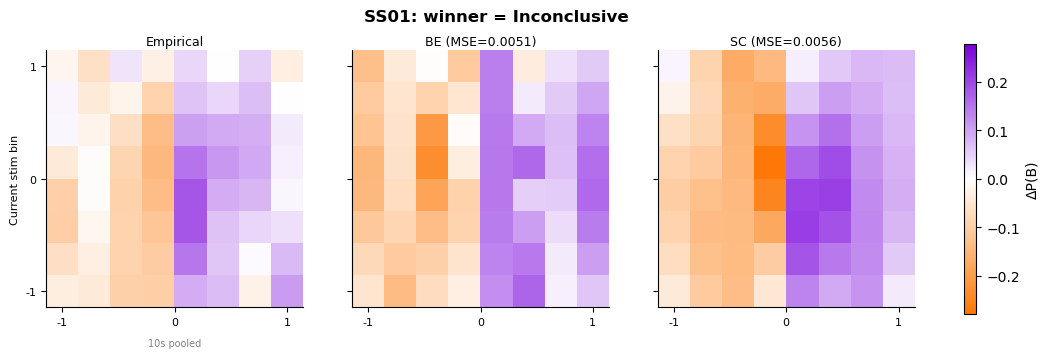

  SS04 BE: MSE=0.00369 | A_repulsion=0.250, eta_learning=0.100, eta_relax=0.400, sigma_noise=0.050
  SS04 SC: MSE=0.00251 | A_repulsion=0.250, gamma=1.000, sigma_update=0.100, sigma_noise=0.133


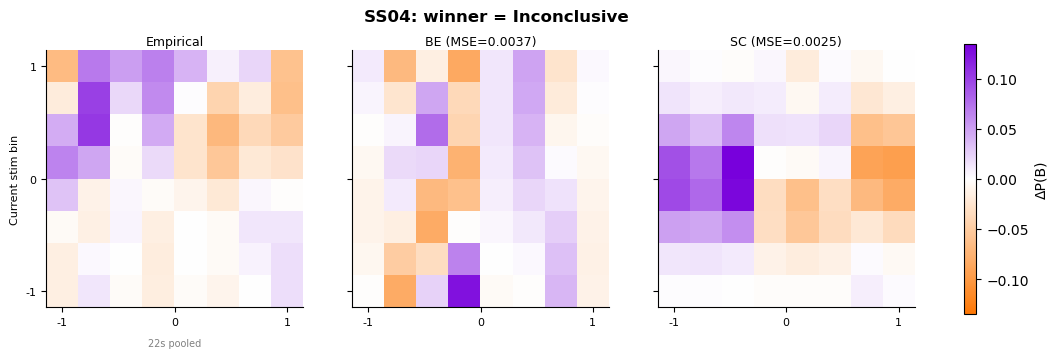

In [17]:
from analysis.grid_search import _sessions_to_arrays
from analysis.cv_utils import get_best_seed_params, format_params
from plotting.cv import plot_param_distributions

for aid in sorted(expert_sessions.keys()):
    sessions = expert_sessions[aid]
    results_list = all_results[aid]

    # Empirical UM (new architecture)
    emp_um, _, emp_info = compute_update_matrix_from_sessions(
        sessions, method='pool', n_bins=N_BINS,
    )

    # Pool session arrays for model simulation
    data = _sessions_to_arrays(sessions)

    # Simulate best-fit model for each model type
    model_ums = {}
    model_errors = {}

    for model_name in ['BE', 'SC']:
        raw_params, seed = get_best_seed_params(results_list, model_name)
        if raw_params is None:
            continue

        named = format_params(model_name, raw_params)
        # Normalise param names for _simulate_um
        sp = named.get('sigma_noise', named.get('sigma_percep', 0.15))
        ar = named.get('A_repulsion', 0.10)

        if model_name == 'BE':
            p1 = named.get('eta_learning', 0.35)
            p2 = named.get('eta_relax', 0.12)
            p1_name, p2_name = 'eta_learning', 'eta_relax'
        else:
            p1 = named.get('gamma', 0.95)
            p2 = named.get('sigma_update', 0.30)
            p1_name, p2_name = 'gamma', 'sigma_update'

        try:
            model_um = _simulate_um(
                model_name,
                data['stimuli'], data['categories'],
                data['no_response'], data['not_blockstart'],
                sp, ar, p1, p2, p1_name, p2_name,
                seed, burn_in=1000, n_bins=N_BINS,
            )
            model_ums[model_name] = model_um
            model_errors[model_name] = matrix_error(model_um, emp_um)

            param_str = ', '.join(f'{k}={v:.3f}' for k, v in named.items())
            print(f'  {aid} {model_name}: MSE={model_errors[model_name]:.5f} | {param_str}')
        except Exception as e:
            print(f'  {aid} {model_name}: simulation failed — {e}')

    # Plot: empirical + both models
    if model_ums:
        winner_row = comparison_df[comparison_df['animal_id'] == aid]
        winner = winner_row['winner'].values[0] if len(winner_row) > 0 else '?'

        phases = {'Empirical': emp_um}
        annotations = {'Empirical': f'{emp_info["n_sessions"]}s pooled'}
        for mn, um in model_ums.items():
            err = model_errors[mn]
            marker = ' ★' if mn == winner else ''
            phases[f'{mn} (MSE={err:.4f}){marker}'] = um
            annotations[f'{mn} (MSE={err:.4f}){marker}'] = ''

        fig, axes = plot_phase_update_matrices(
            phases,
            suptitle=f'{aid}: winner = {winner}',
            annotations=annotations,
        )
        plt.show()

## 8. Parameter Distributions Across Seeds

For each animal, show how best-fit parameters vary across the 64
random seeds. Tight distributions = robust fit; broad = sensitive
to noise.

In [15]:
param_df = extract_param_df(all_results)
print(f'Parameter DataFrame: {len(param_df)} rows')
param_df.head(10)

Parameter DataFrame: 16 rows


,animal_id,model,seed,fold,A_repulsion,eta_learning,eta_relax,sigma_noise,gamma,sigma_update
0,SS01,BE,1,0,0.25,0.100000,0.050000,0.30,NaN,NaN
1,SS01,BE,1,1,0.00,0.214286,0.050000,0.05,NaN,NaN
2,SS01,SC,1,0,0.50,NaN,NaN,0.30,0.614286,1.0
3,SS01,SC,1,1,0.25,NaN,NaN,0.30,0.742857,1.0
4,SS01,BE,2,0,0.00,0.100000,0.166667,0.30,NaN,NaN
5,SS01,BE,2,1,0.00,0.214286,0.283333,0.05,NaN,NaN
6,SS01,SC,2,0,0.50,NaN,NaN,0.30,0.614286,1.0
7,SS01,SC,2,1,0.25,NaN,NaN,0.30,0.742857,0.7
8,SS04,BE,1,0,0.00,0.100000,0.400000,0.05,NaN,NaN
9,SS04,BE,1,1,0.00,0.100000,0.283333,0.05,NaN,NaN


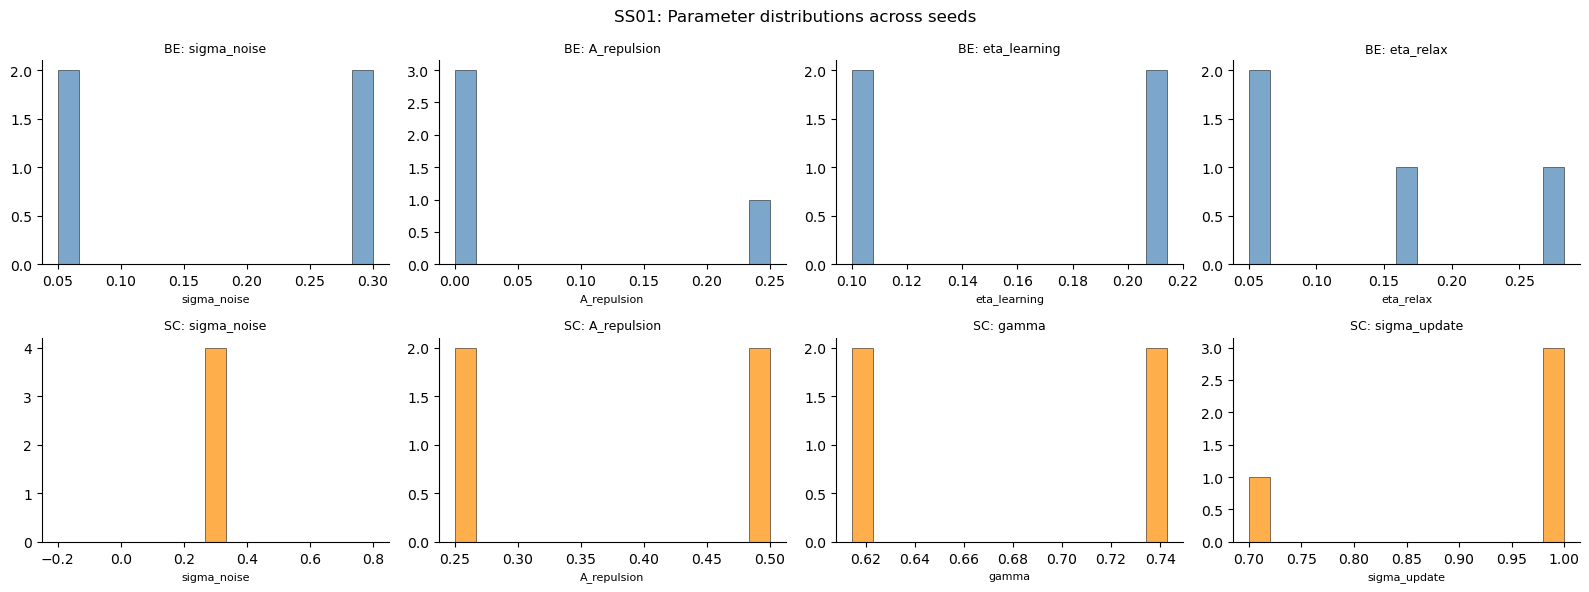

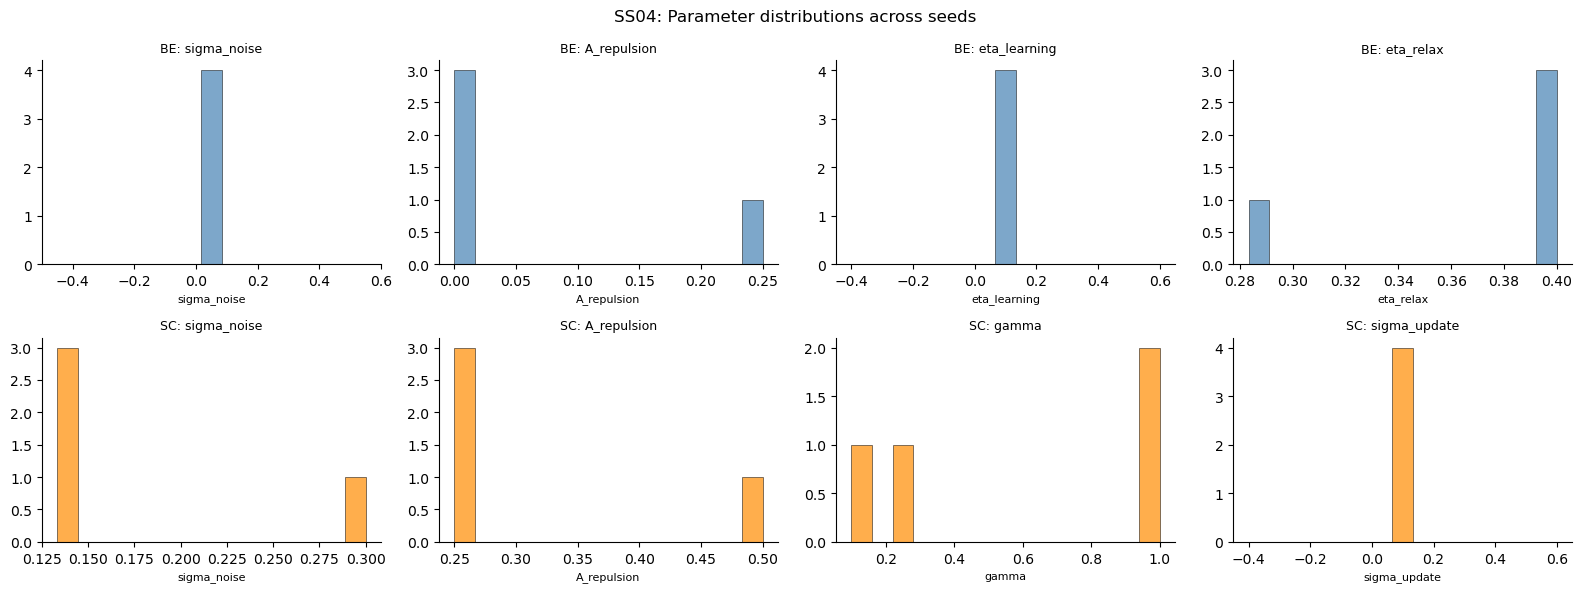

In [18]:
for aid in sorted(all_results.keys()):
    fig = plot_param_distributions(
        param_df, aid, output_dir=str(OUTPUT_DIR),
    )
    plt.show()
    plt.close(fig)

## 9. Save

In [19]:
long_df.to_csv(OUTPUT_DIR / 'cv_test_errors_long.csv', index=False)
comparison_df.to_csv(OUTPUT_DIR / 'cv_comparison_anova.csv', index=False)
summary_df.to_csv(OUTPUT_DIR / 'cv_summary.csv', index=False)
param_df.to_csv(OUTPUT_DIR / 'cv_best_params.csv', index=False)

print('Saved:')
for f in ['cv_test_errors_long.csv', 'cv_comparison_anova.csv',
          'cv_summary.csv', 'cv_best_params.csv']:
    print(f'  {OUTPUT_DIR / f}')

Saved:
  ../results/cv/figures/cv_test_errors_long.csv
  ../results/cv/figures/cv_comparison_anova.csv
  ../results/cv/figures/cv_summary.csv
  ../results/cv/figures/cv_best_params.csv


## Interpretation

**Clear winner (p < 0.05, consistent across seeds):** The winning model
better captures this animal's serial dependence structure during expert
performance. This classification carries forward to 4b (post-shift
parameter tracking) and 6a (opto predictions).

**Non-significant (NS):** Either both models fit equally well (both
capture the animal's behaviour), or neither fits well (flat update
matrix, weak serial dependence). Check the empirical UM — if it's
noisy/flat, the animal may not have strong enough serial dependence
to distinguish models.

**Parameter consistency across seeds:** If best-fit parameters vary
widely across seeds, the grid is too coarse or the cost surface has
multiple minima. Consider the coarse → fine grid refinement.

**Update matrix visual check:** The empirical UM should show either a
win-stay stripe (BE signature) or a more diffuse pattern (SC signature).
The winning model's simulated UM should visually match the empirical one.
If the ANOVA says BE wins but the UM doesn't look like a stripe, the
classification may be driven by a different feature of the UM.

**Next**: notebook 3b (SBI comparison), then 3c (consensus).